# Tarea 4 · Técnicas de captura de datos sobre fuentes deportivas

## Análisis del rendimiento competitivo de Cabo Verde antes del Mundial 2026 mediante web scraping

**Alumno:** Salvador Álvarez Sánchez  
**Máster:** Python Avanzado Aplicado al Deporte  
**Módulo:** 4 · Técnicas de captura de datos sobre fuentes deportivas  
**Fuente utilizada:** 11v11.com  
**Caso de estudio:** Cabo Verde como rival de España en la fase de grupos del Mundial 2026

---

### Pregunta principal del proyecto

> ¿Qué rendimiento competitivo presenta Cabo Verde antes de enfrentarse a España y qué información puedo extraer de sus resultados disponibles en 11v11?

En este notebook desarrollo un proceso completo de captura de datos deportivos sobre una única fuente web. El trabajo incluye análisis previo, extracción, limpieza, transformación, análisis exploratorio, visualización, automatización, logging y conclusiones deportivas.


## 1. Introducción

El Mundial 2026 permite analizar selecciones menos mediáticas que pueden tener un papel relevante en la competición. En este caso, el estudio se centra en Cabo Verde, selección que se enfrentará a España en la fase de grupos.

La finalidad del trabajo es transformar datos disponibles en una web deportiva en información útil para el análisis previo de un partido. Para ello se utiliza 11v11, una fuente especializada en resultados históricos de selecciones nacionales.

La fuente no ofrece métricas avanzadas como xG, posesión, datos físicos o acciones individuales, por lo que el análisis se centra únicamente en lo que sí proporciona de forma fiable: partidos, rivales, marcadores, competiciones y resultados.


## 2. Objetivos

### Objetivo general

Analizar el rendimiento competitivo reciente de la selección de Cabo Verde utilizando técnicas de web scraping aplicadas a una fuente deportiva especializada.

### Objetivos específicos

- Extraer automáticamente partidos disponibles de Cabo Verde desde 11v11.
- Obtener fecha, rival, marcador, competición y resultado.
- Calcular victorias, empates, derrotas y porcentaje de victorias.
- Medir fortaleza ofensiva mediante goles a favor, partidos sin marcar y partidos con dos o más goles.
- Medir fortaleza defensiva mediante goles encajados y porterías a cero.
- Clasificar rivales por nivel competitivo para interpretar mejor los resultados.
- Comparar métricas básicas de Cabo Verde con España utilizando la misma fuente.
- Generar visualizaciones que faciliten la interpretación deportiva.
- Automatizar el proceso y registrar la ejecución mediante logging.


## 3. Análisis y planificación de la fuente

La fuente seleccionada es **11v11.com**, una web con información histórica sobre selecciones nacionales. Para este proyecto se utilizan las páginas de partidos de Cabo Verde y España.

Los datos relevantes que se pretenden extraer son:

- Fecha del partido.
- Equipos participantes.
- Resultado desde la perspectiva del equipo analizado.
- Marcador.
- Competición.
- Rival.
- Condición de local o visitante.
- Goles a favor y en contra en el marcador principal.
- Resultado final oficial del partido según la columna `Result`.

La estrategia de scraping consiste en:

1. Acceder a la página de partidos de la selección.
2. Revisar de forma informativa el archivo `robots.txt`.
3. Descargar el HTML mediante `requests`.
4. Inspeccionar la estructura HTML con `BeautifulSoup`.
5. Extraer las tablas HTML mediante `pandas.read_html`.
6. Identificar la tabla que contiene los partidos.
7. Limpiar y normalizar los datos.
8. Calcular variables derivadas.
9. Guardar los datos en CSV.
10. Realizar análisis exploratorio y visualizaciones.
11. Automatizar el proceso completo.

El número de partidos analizados depende de los registros que la fuente muestre en la tabla extraída en el momento de ejecución. Por este motivo, el trabajo habla de **partidos disponibles en la fuente** y no de un número fijo de encuentros.


## 4. Consideraciones éticas y legales

El scraping se realiza con finalidad académica y de análisis deportivo. Durante el proceso se aplican buenas prácticas:

- Se utiliza una fuente pública.
- Se identifica la petición con un User-Agent.
- Se realizan pocas solicitudes.
- Se aplican pausas aleatorias entre peticiones.
- Se registra el proceso mediante logging.
- Se revisa de forma informativa el archivo `robots.txt`.
- No se accede a zonas privadas.
- No se utilizan credenciales ni se eluden sistemas de seguridad.
- No se realiza descarga masiva de contenido.

La comprobación de `robots.txt` se registra como parte del control ético del proceso. Además, el scraper incluye pausas, reintentos controlados y una cantidad mínima de solicitudes para evitar sobrecargar el servidor.

El objetivo no es replicar el contenido de la web, sino capturar una muestra controlada de datos para construir un análisis reproducible.


In [1]:
# ============================================================
# 5. Instalación / importación de librerías
# ============================================================

# Si alguna librería no está instalada, se puede ejecutar:
# !pip install requests beautifulsoup4 lxml pandas matplotlib numpy

import os
import re
import time
import random
import logging
import urllib.robotparser

from io import StringIO
from urllib.parse import urljoin

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

print("Librerías importadas correctamente")

Librerías importadas correctamente


In [2]:
# ============================================================
# 6. Configuración general del proyecto
# ============================================================

BASE_URL = "https://www.11v11.com"

URL_CABO_VERDE = "https://www.11v11.com/teams/cape-verde-islands/tab/matches/"
URL_ESPANA = "https://www.11v11.com/teams/spain/tab/matches/"

DATA_DIR = "datos_tarea4_cabo_verde"
os.makedirs(DATA_DIR, exist_ok=True)

LOG_FILE = os.path.join(DATA_DIR, "scraping_tarea4.log")

logging.basicConfig(
    filename=LOG_FILE,
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    filemode="w"
)

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/125.0 Safari/537.36 - Academic scraping project"
    ),
    "Accept-Language": "es-ES,es;q=0.9,en;q=0.8"
}

print("Configuración cargada correctamente")

Configuración cargada correctamente


In [3]:
# ============================================================
# 7. Comprobación informativa de robots.txt
# ============================================================

def comprobar_robots(url: str, user_agent: str = "*") -> bool:
    """
    Comprueba de forma informativa si robots.txt permite acceder a una URL.
    La función registra el resultado en el log, pero no detiene el notebook.
    """
    robots_url = urljoin(BASE_URL, "/robots.txt")
    rp = urllib.robotparser.RobotFileParser()

    try:
        rp.set_url(robots_url)
        rp.read()

        permitido = rp.can_fetch(user_agent, url)

        if permitido:
            mensaje = f"robots.txt revisado: acceso permitido para {url}"
            logging.info(mensaje)
        else:
            mensaje = f"robots.txt revisado: acceso no confirmado para {url}. Se aplican pausas, pocas solicitudes y uso académico."
            logging.warning(mensaje)

        print(mensaje)
        return permitido

    except Exception as e:
        mensaje = f"No se pudo comprobar robots.txt para {url}. Se continúa con límites de tasa y pocas solicitudes."
        logging.warning(f"{mensaje} Error: {e}")
        print(mensaje)
        return False


robots_cabo_verde = comprobar_robots(URL_CABO_VERDE)
robots_espana = comprobar_robots(URL_ESPANA)

print("Comprobación de robots.txt registrada en el log.")

robots.txt revisado: acceso no confirmado para https://www.11v11.com/teams/cape-verde-islands/tab/matches/. Se aplican pausas, pocas solicitudes y uso académico.
robots.txt revisado: acceso no confirmado para https://www.11v11.com/teams/spain/tab/matches/. Se aplican pausas, pocas solicitudes y uso académico.
Comprobación de robots.txt registrada en el log.


In [4]:
# ============================================================
# 8. Función de descarga con pausas y reintentos
# ============================================================

def descargar_html(url: str, max_reintentos: int = 3, pausa_min: float = 2.0, pausa_max: float = 4.0) -> str:
    """
    Descarga el HTML de una página con reintentos, pausas aleatorias y control de errores.
    """
    for intento in range(1, max_reintentos + 1):
        try:
            pausa = random.uniform(pausa_min, pausa_max)
            time.sleep(pausa)

            response = requests.get(url, headers=HEADERS, timeout=25)
            response.raise_for_status()

            logging.info(f"Descarga correcta: {url}")
            return response.text

        except requests.exceptions.RequestException as e:
            logging.warning(f"Intento {intento}/{max_reintentos} fallido para {url}: {e}")

            if intento == max_reintentos:
                logging.error(f"No se pudo descargar la página: {url}")
                raise

            time.sleep(2 * intento)

## 9. Inspección inicial del HTML con BeautifulSoup

Antes de extraer las tablas con `pandas.read_html`, realizo una inspección sencilla del HTML con `BeautifulSoup`. Esta revisión permite comprobar que la página responde correctamente y que contiene estructura HTML interpretable.


In [5]:
# ============================================================
# 9. Inspección inicial con BeautifulSoup
# ============================================================

html_cabo_verde = descargar_html(URL_CABO_VERDE)
soup_cabo_verde = BeautifulSoup(html_cabo_verde, "html.parser")

titulo_pagina = soup_cabo_verde.title.get_text(strip=True) if soup_cabo_verde.title else "Sin título"
numero_tablas_html = len(soup_cabo_verde.find_all("table"))

print("Título de la página:", titulo_pagina)
print("Número de tablas HTML detectadas:", numero_tablas_html)

logging.info(f"Título detectado con BeautifulSoup: {titulo_pagina}")
logging.info(f"Tablas HTML detectadas con BeautifulSoup: {numero_tablas_html}")

Título de la página: Cape Verde Islands football
	team 'A' international match record
Número de tablas HTML detectadas: 1


In [6]:
# ============================================================
# 10. Funciones para extraer y seleccionar tablas
# ============================================================

def extraer_tablas_11v11(url: str) -> list:
    """
    Extrae todas las tablas HTML de una página de 11v11.
    Primero descarga el HTML con requests y después utiliza pandas.read_html.
    """
    html = descargar_html(url)
    tablas = pd.read_html(StringIO(html))
    logging.info(f"Tablas encontradas en {url}: {len(tablas)}")
    return tablas


def seleccionar_tabla_partidos(tablas: list) -> pd.DataFrame:
    """
    Selecciona la tabla que contiene partidos.
    En 11v11 suele incluir columnas como Date, Match, Result, Score y Competition.
    """
    posibles = []

    for i, tabla in enumerate(tablas):
        columnas = [str(c).strip().lower() for c in tabla.columns]
        texto_columnas = " ".join(columnas)

        condicion_1 = "date" in texto_columnas and "match" in texto_columnas
        condicion_2 = "score" in texto_columnas and "competition" in texto_columnas

        if condicion_1 or condicion_2:
            posibles.append((i, tabla))

    if not posibles:
        raise ValueError(
            "No se encontró una tabla de partidos reconocible. "
            "Puede haber cambiado la estructura de la web."
        )

    indice, df = max(posibles, key=lambda x: len(x[1]))

    logging.info(f"Tabla de partidos seleccionada: índice {indice}, filas {len(df)}")
    return df.copy()

In [7]:
# ============================================================
# 11. Funciones de limpieza y normalización
# ============================================================

VARIANTES_CABO_VERDE = ["Cape Verde Islands", "Cape Verde", "Cabo Verde"]
VARIANTES_ESPANA = ["Spain", "España"]


def limpiar_texto(x):
    """
    Limpia espacios duplicados y convierte el valor a texto.
    """
    if pd.isna(x):
        return np.nan

    return re.sub(r"\s+", " ", str(x)).strip()


def parsear_score(score):
    """
    Extrae el marcador principal del partido.

    Ejemplos:
    - '3-0' -> 3, 0
    - '0-0 (5-4)' -> 0, 0
    - '1-1 (0-2)' -> 1, 1
    """
    if pd.isna(score):
        return np.nan, np.nan

    texto = str(score).strip()
    patron = re.search(r"(\d+)\s*[-–]\s*(\d+)", texto)

    if patron:
        return int(patron.group(1)), int(patron.group(2))

    return np.nan, np.nan


def tiene_resolucion_posterior(score):
    """
    Detecta si el marcador incluye información entre paréntesis.
    Esto suele indicar penaltis u otro criterio de resolución tras empate.
    """
    if pd.isna(score):
        return False

    return "(" in str(score) and ")" in str(score)


def extraer_rival_y_goles(row, variantes_equipo):
    """
    Identifica si el equipo analizado aparece como local o visitante y calcula
    rival, condición, goles a favor y goles en contra desde su perspectiva.
    """
    match = limpiar_texto(row.get("Match", ""))
    score = row.get("Score", np.nan)

    goles_1, goles_2 = parsear_score(score)

    if pd.isna(match):
        return pd.Series([np.nan, np.nan, np.nan, np.nan])

    partes = re.split(r"\s+v\s+|\s+vs\s+", match, flags=re.IGNORECASE)

    if len(partes) == 2:
        local = limpiar_texto(partes[0])
        visitante = limpiar_texto(partes[1])
    else:
        local, visitante = np.nan, np.nan

    variantes_norm = [v.lower() for v in variantes_equipo]
    local_norm = str(local).lower()
    visitante_norm = str(visitante).lower()

    if any(v in local_norm for v in variantes_norm):
        rival = visitante
        condicion = "Local"
        gf, gc = goles_1, goles_2

    elif any(v in visitante_norm for v in variantes_norm):
        rival = local
        condicion = "Visitante"
        gf, gc = goles_2, goles_1

    else:
        rival = np.nan
        condicion = np.nan
        gf, gc = np.nan, np.nan

    return pd.Series([rival, condicion, gf, gc])


def normalizar_partidos(
    df_raw: pd.DataFrame,
    nombre_equipo: str,
    variantes_equipo: list,
    n_ultimos: int = 30,
    solo_oficiales: bool = True
) -> pd.DataFrame:
    """
    Limpia la tabla de partidos y calcula variables analíticas.
    """
    df = df_raw.copy()
    df.columns = [limpiar_texto(c) for c in df.columns]

    columnas_necesarias = [
        c for c in ["Date", "Match", "Result", "Score", "Competition"]
        if c in df.columns
    ]

    df = df[columnas_necesarias].copy()

    for col in df.columns:
        df[col] = df[col].apply(limpiar_texto)

    if "Date" in df.columns:
        df["Fecha"] = pd.to_datetime(df["Date"], errors="coerce", dayfirst=True)
    else:
        df["Fecha"] = pd.NaT

    df = df.dropna(subset=["Match", "Score"], how="any").copy()

    if solo_oficiales and "Competition" in df.columns:
        patron_amistosos = r"friendly|friendlies|international friendly|friendly international"
        df = df[
            ~df["Competition"].str.lower().str.contains(patron_amistosos, na=False)
        ].copy()

    df[["Rival", "Condicion", "Goles_Favor", "Goles_Contra"]] = df.apply(
        lambda row: extraer_rival_y_goles(row, variantes_equipo),
        axis=1
    )

    # Resultado oficial desde la perspectiva del equipo según 11v11.
    # W = victoria, D = empate, L = derrota.
    if "Result" in df.columns:
        df["Resultado"] = df["Result"].str.upper().str.extract(r"([WDL])", expand=False)
    else:
        df["Resultado"] = np.where(
            df["Goles_Favor"] > df["Goles_Contra"],
            "W",
            np.where(df["Goles_Favor"] < df["Goles_Contra"], "L", "D")
        )

    mapa_resultado = {
        "W": "Victoria",
        "D": "Empate",
        "L": "Derrota"
    }

    df["Resultado_Texto"] = df["Resultado"].map(mapa_resultado)
    df["Equipo"] = nombre_equipo

    df = df.sort_values("Fecha", ascending=False).head(n_ultimos).copy()
    df = df.sort_values("Fecha", ascending=True).reset_index(drop=True)

    df["Diferencia_Goles"] = df["Goles_Favor"] - df["Goles_Contra"]
    df["Porteria_Cero"] = df["Goles_Contra"] == 0
    df["Sin_Marcar"] = df["Goles_Favor"] == 0
    df["Marca_2_o_mas"] = df["Goles_Favor"] >= 2
    df["Resuelto_Tras_Empate"] = df["Score"].apply(tiene_resolucion_posterior)

    df["Nota_Marcador"] = np.where(
        df["Resuelto_Tras_Empate"],
        "Marcador principal empatado; resultado oficial decidido posteriormente",
        "Marcador principal"
    )

    return df

In [8]:
# ============================================================
# 12. Scraping de Cabo Verde y España
# ============================================================

N_PARTIDOS_SOLICITADOS = 30

try:
    tablas_cabo_verde = extraer_tablas_11v11(URL_CABO_VERDE)
    tabla_cabo_verde_raw = seleccionar_tabla_partidos(tablas_cabo_verde)

    partidos_cabo_verde = normalizar_partidos(
        tabla_cabo_verde_raw,
        nombre_equipo="Cabo Verde",
        variantes_equipo=VARIANTES_CABO_VERDE,
        n_ultimos=N_PARTIDOS_SOLICITADOS,
        solo_oficiales=True
    )

    tablas_espana = extraer_tablas_11v11(URL_ESPANA)
    tabla_espana_raw = seleccionar_tabla_partidos(tablas_espana)

    partidos_espana = normalizar_partidos(
        tabla_espana_raw,
        nombre_equipo="España",
        variantes_equipo=VARIANTES_ESPANA,
        n_ultimos=N_PARTIDOS_SOLICITADOS,
        solo_oficiales=True
    )

    print("Scraping completado correctamente")
    print("Partidos solicitados por equipo:", N_PARTIDOS_SOLICITADOS)
    print("Partidos disponibles Cabo Verde:", len(partidos_cabo_verde))
    print("Partidos disponibles España:", len(partidos_espana))

except Exception as e:
    logging.error(f"Error general en el scraping: {e}")
    raise

Scraping completado correctamente
Partidos solicitados por equipo: 30
Partidos disponibles Cabo Verde: 8
Partidos disponibles España: 6


## 13. Vista previa de los datos obtenidos

Una vez capturados los datos, reviso las primeras filas para comprobar que la estructura es correcta y que las variables calculadas tienen sentido.

Es importante tener en cuenta que 11v11 puede devolver menos partidos de los solicitados según la disponibilidad de la tabla en el momento de ejecución. Por este motivo, el análisis se realiza sobre los registros disponibles.


In [9]:
partidos_cabo_verde.head(10)

,Date,Match,Result,Score,Competition,Fecha,Rival,Condicion,Goles_Favor,Goles_Contra,Resultado,Resultado_Texto,Equipo,Diferencia_Goles,Porteria_Cero,Sin_Marcar,Marca_2_o_mas,Resuelto_Tras_Empate,Nota_Marcador
0,04 Sep 2025,Mauritius v Cape Verde Islands,W,0-2,FIFA World Cup,2025-09-04,Mauritius,Visitante,2,0,W,Victoria,Cabo Verde,2,True,False,True,False,Marcador principal
1,09 Sep 2025,Cape Verde Islands v Cameroon,W,1-0,FIFA World Cup,2025-09-09,Cameroon,Local,1,0,W,Victoria,Cabo Verde,1,True,False,False,False,Marcador principal
2,08 Oct 2025,Libya v Cape Verde Islands,D,3-3,FIFA World Cup,2025-10-08,Libya,Visitante,3,3,D,Empate,Cabo Verde,0,False,False,True,False,Marcador principal
3,13 Oct 2025,Cape Verde Islands v Swaziland,W,3-0,FIFA World Cup,2025-10-13,Swaziland,Local,3,0,W,Victoria,Cabo Verde,3,True,False,True,False,Marcador principal
4,13 Nov 2025,Iran v Cape Verde Islands,L,0-0 (5-4),Al Ain International Cup,2025-11-13,Iran,Visitante,0,0,L,Derrota,Cabo Verde,0,True,True,False,True,Marcador principal empatado; resultado oficial...
5,17 Nov 2025,Cape Verde Islands v Egypt,L,1-1 (0-2),Al Ain International Cup,2025-11-17,Egypt,Local,1,1,L,Derrota,Cabo Verde,0,False,False,False,True,Marcador principal empatado; resultado oficial...
6,27 Mar 2026,Chile v Cape Verde Islands,L,4-2,FIFA Series,2026-03-27,Chile,Visitante,2,4,L,Derrota,Cabo Verde,-2,False,False,True,False,Marcador principal
7,30 Mar 2026,Cape Verde Islands v Finland,W,1-1 (4-2),FIFA Series,2026-03-30,Finland,Local,1,1,W,Victoria,Cabo Verde,0,False,False,False,True,Marcador principal empatado; resultado oficial...


In [10]:
partidos_espana.head(10)

,Date,Match,Result,Score,Competition,Fecha,Rival,Condicion,Goles_Favor,Goles_Contra,Resultado,Resultado_Texto,Equipo,Diferencia_Goles,Porteria_Cero,Sin_Marcar,Marca_2_o_mas,Resuelto_Tras_Empate,Nota_Marcador
0,04 Sep 2025,Bulgaria v Spain,W,0-3,FIFA World Cup,2025-09-04,Bulgaria,Visitante,3,0,W,Victoria,España,3,True,False,True,False,Marcador principal
1,07 Sep 2025,Turkey v Spain,W,0-6,FIFA World Cup,2025-09-07,Turkey,Visitante,6,0,W,Victoria,España,6,True,False,True,False,Marcador principal
2,11 Oct 2025,Spain v Georgia,W,2-0,FIFA World Cup,2025-10-11,Georgia,Local,2,0,W,Victoria,España,2,True,False,True,False,Marcador principal
3,14 Oct 2025,Spain v Bulgaria,W,4-0,FIFA World Cup,2025-10-14,Bulgaria,Local,4,0,W,Victoria,España,4,True,False,True,False,Marcador principal
4,15 Nov 2025,Georgia v Spain,W,0-4,FIFA World Cup,2025-11-15,Georgia,Visitante,4,0,W,Victoria,España,4,True,False,True,False,Marcador principal
5,18 Nov 2025,Spain v Turkey,D,2-2,FIFA World Cup,2025-11-18,Turkey,Local,2,2,D,Empate,España,0,False,False,True,False,Marcador principal


## 14. Revisión de partidos decididos tras empate

Algunos partidos pueden aparecer con marcadores como `0-0 (5-4)` o `1-1 (0-2)`. En estos casos, el marcador principal refleja los goles del partido, mientras que la columna `Result` indica el resultado oficial final.

Para evitar confusiones, se crea la variable `Resuelto_Tras_Empate`, que identifica estos partidos.


In [11]:
partidos_cabo_verde[
    partidos_cabo_verde["Resuelto_Tras_Empate"]
][[
    "Fecha",
    "Match",
    "Result",
    "Score",
    "Resultado_Texto",
    "Goles_Favor",
    "Goles_Contra",
    "Nota_Marcador"
]]

,Fecha,Match,Result,Score,Resultado_Texto,Goles_Favor,Goles_Contra,Nota_Marcador
4,2025-11-13,Iran v Cape Verde Islands,L,0-0 (5-4),Derrota,0,0,Marcador principal empatado; resultado oficial...
5,2025-11-17,Cape Verde Islands v Egypt,L,1-1 (0-2),Derrota,1,1,Marcador principal empatado; resultado oficial...
7,2026-03-30,Cape Verde Islands v Finland,W,1-1 (4-2),Victoria,1,1,Marcador principal empatado; resultado oficial...


## 15. Guardado de datos limpios

Los datos procesados se exportan a CSV. De esta forma, el análisis queda respaldado por archivos estructurados que pueden reutilizarse o revisarse posteriormente.


In [12]:
# ============================================================
# 15. Guardado de datos limpios
# ============================================================

csv_cabo_verde = os.path.join(DATA_DIR, "partidos_cabo_verde_11v11_limpios.csv")
csv_espana = os.path.join(DATA_DIR, "partidos_espana_11v11_limpios.csv")

partidos_cabo_verde.to_csv(csv_cabo_verde, index=False, encoding="utf-8-sig")
partidos_espana.to_csv(csv_espana, index=False, encoding="utf-8-sig")

print("Archivos guardados:")
print(csv_cabo_verde)
print(csv_espana)

Archivos guardados:
datos_tarea4_cabo_verde\partidos_cabo_verde_11v11_limpios.csv
datos_tarea4_cabo_verde\partidos_espana_11v11_limpios.csv


## 16. Análisis exploratorio de datos

En esta fase se calculan estadísticas descriptivas para resumir el rendimiento reciente de Cabo Verde y compararlo con España.

Las métricas principales son:

- Partidos disponibles.
- Victorias, empates y derrotas oficiales.
- Porcentaje de victorias oficiales.
- Goles a favor.
- Goles en contra.
- Goles a favor por partido.
- Goles encajados por partido.
- Porterías a cero.
- Partidos sin marcar.
- Partidos marcando dos o más goles.

En los partidos resueltos tras empate, los goles a favor y en contra proceden del marcador principal, mientras que el resultado oficial procede de la columna `Result` de 11v11.


In [13]:
# ============================================================
# 16.1 Función de resumen estadístico
# ============================================================

def resumen_equipo(df: pd.DataFrame) -> pd.Series:
    total = len(df)

    victorias = (df["Resultado"] == "W").sum()
    empates = (df["Resultado"] == "D").sum()
    derrotas = (df["Resultado"] == "L").sum()

    resumen = {
        "Partidos disponibles": total,
        "Victorias oficiales": victorias,
        "Empates oficiales": empates,
        "Derrotas oficiales": derrotas,
        "% Victorias oficiales": round(victorias / total * 100, 2) if total else 0,
        "Goles a favor": int(df["Goles_Favor"].sum()),
        "Goles en contra": int(df["Goles_Contra"].sum()),
        "Goles favor / partido": round(df["Goles_Favor"].mean(), 2) if total else 0,
        "Goles contra / partido": round(df["Goles_Contra"].mean(), 2) if total else 0,
        "Porterías a cero": int(df["Porteria_Cero"].sum()),
        "% Porterías a cero": round(df["Porteria_Cero"].mean() * 100, 2) if total else 0,
        "Partidos sin marcar": int(df["Sin_Marcar"].sum()),
        "% Partidos sin marcar": round(df["Sin_Marcar"].mean() * 100, 2) if total else 0,
        "Partidos con 2+ goles": int(df["Marca_2_o_mas"].sum()),
        "% Partidos con 2+ goles": round(df["Marca_2_o_mas"].mean() * 100, 2) if total else 0,
        "Partidos resueltos tras empate": int(df["Resuelto_Tras_Empate"].sum()),
    }

    return pd.Series(resumen)


resumen_cabo_verde = resumen_equipo(partidos_cabo_verde)
resumen_espana = resumen_equipo(partidos_espana)

resumen_comparativo = pd.DataFrame({
    "Cabo Verde": resumen_cabo_verde,
    "España": resumen_espana
})

resumen_comparativo

,Cabo Verde,España
Partidos disponibles,8.00,6.00
Victorias oficiales,4.00,5.00
Empates oficiales,1.00,1.00
Derrotas oficiales,3.00,0.00
% Victorias oficiales,50.00,83.33
Goles a favor,13.00,21.00
Goles en contra,9.00,2.00
Goles favor / partido,1.62,3.50
Goles contra / partido,1.12,0.33
Porterías a cero,4.00,5.00


## 17. Visualización 1: resultados oficiales disponibles de Cabo Verde

Este gráfico permite ver rápidamente cuántas victorias, empates y derrotas oficiales acumula Cabo Verde en la muestra disponible.


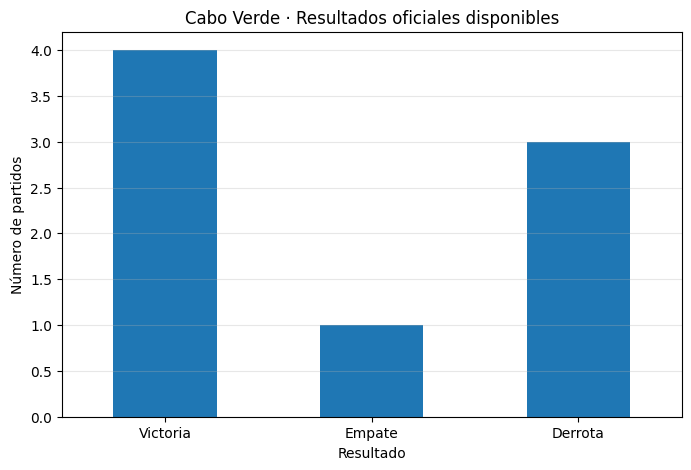

In [14]:
# ============================================================
# 17. Gráfico de victorias, empates y derrotas
# ============================================================

conteo_resultados = (
    partidos_cabo_verde["Resultado_Texto"]
    .value_counts()
    .reindex(["Victoria", "Empate", "Derrota"])
    .fillna(0)
)

plt.figure(figsize=(8, 5))
conteo_resultados.plot(kind="bar")

plt.title("Cabo Verde · Resultados oficiales disponibles")
plt.xlabel("Resultado")
plt.ylabel("Número de partidos")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

## 18. Visualización 2: evolución temporal de la diferencia de goles

La diferencia de goles ayuda a interpretar si Cabo Verde está compitiendo con solvencia o si ha sufrido partidos con marcadores adversos.

En partidos resueltos posteriormente tras empate, esta diferencia corresponde al marcador principal del encuentro.


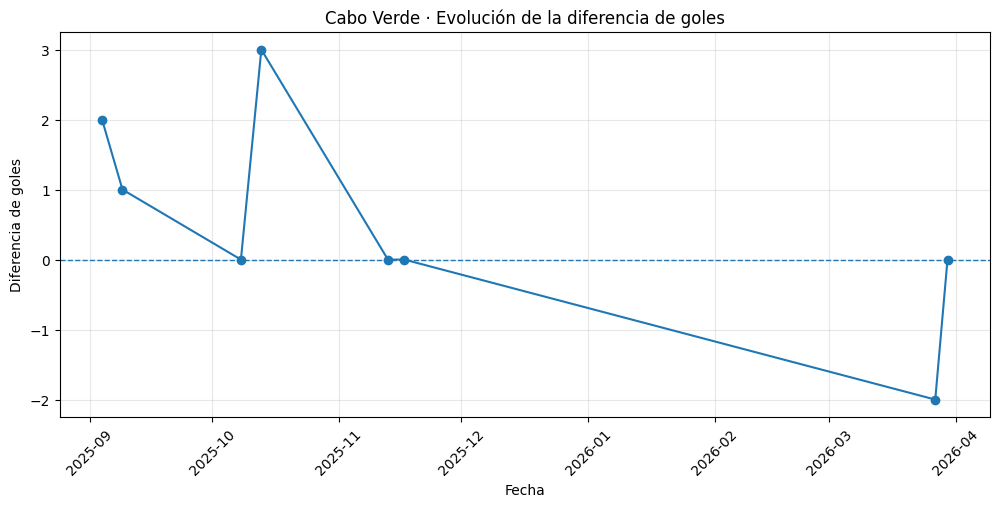

In [15]:
# ============================================================
# 18. Evolución temporal de la diferencia de goles
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    partidos_cabo_verde["Fecha"],
    partidos_cabo_verde["Diferencia_Goles"],
    marker="o"
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Cabo Verde · Evolución de la diferencia de goles")
plt.xlabel("Fecha")
plt.ylabel("Diferencia de goles")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.show()

## 19. Visualización 3: goles a favor frente a goles en contra

Este gráfico resume la producción ofensiva y el rendimiento defensivo acumulado en los partidos disponibles.


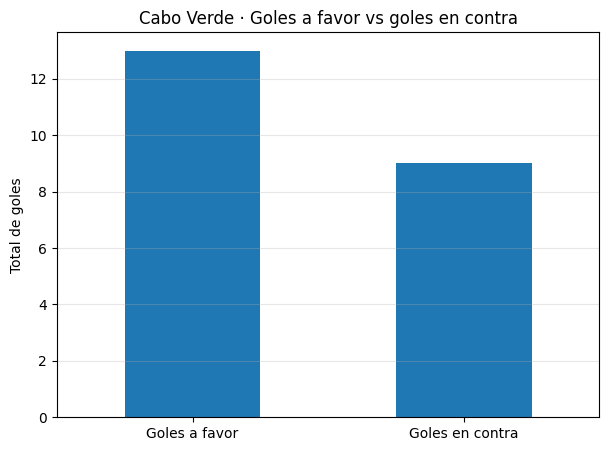

In [16]:
# ============================================================
# 19. Goles a favor vs goles en contra
# ============================================================

goles = pd.Series({
    "Goles a favor": partidos_cabo_verde["Goles_Favor"].sum(),
    "Goles en contra": partidos_cabo_verde["Goles_Contra"].sum()
})

plt.figure(figsize=(7, 5))
goles.plot(kind="bar")

plt.title("Cabo Verde · Goles a favor vs goles en contra")
plt.ylabel("Total de goles")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

## 20. Calidad de los rivales

Para interpretar mejor el rendimiento de Cabo Verde, clasifico los rivales en niveles competitivos.

Esta clasificación no procede directamente de 11v11, sino que es una decisión analítica manual documentada dentro del proyecto. El objetivo es diferenciar partidos frente a selecciones de mayor nivel de aquellos disputados ante rivales de menor exigencia.

Los grupos utilizados son:

- **Top África:** selecciones africanas con mayor peso continental o mundialista.
- **Nivel medio:** selecciones competitivas, habituales en fases de clasificación o Copa África.
- **Nivel bajo:** selecciones de menor peso competitivo reciente.
- **Otros / no africano:** selecciones no africanas o rivales no incluidos en la clasificación anterior.


In [17]:
# ============================================================
# 20. Clasificación manual de calidad de rivales
# ============================================================

TOP_AFRICA = {
    "Morocco", "Egypt", "Senegal", "Nigeria", "Algeria", "Cameroon",
    "Ivory Coast", "Côte d'Ivoire", "Tunisia", "Ghana"
}

NIVEL_MEDIO = {
    "South Africa", "Mali", "Burkina Faso", "DR Congo", "Congo DR",
    "Guinea", "Zambia", "Angola", "Libya", "Mauritania", "Uganda",
    "Gabon", "Benin", "Equatorial Guinea", "Mozambique", "Togo",
    "Kenya", "Tanzania"
}

NIVEL_BAJO = {
    "Eswatini", "Swaziland", "Liberia", "Mauritius", "Botswana",
    "Lesotho", "Seychelles", "São Tomé and Príncipe",
    "Sao Tome and Principe", "Central African Republic", "Chad", "Somalia"
}


def clasificar_rival(rival):
    if pd.isna(rival):
        return "Sin clasificar"

    rival_limpio = str(rival).strip()

    if rival_limpio in TOP_AFRICA:
        return "Top África"

    elif rival_limpio in NIVEL_MEDIO:
        return "Nivel medio"

    elif rival_limpio in NIVEL_BAJO:
        return "Nivel bajo"

    else:
        return "Otros / no africano"


partidos_cabo_verde["Nivel_Rival"] = partidos_cabo_verde["Rival"].apply(clasificar_rival)

rendimiento_por_nivel = partidos_cabo_verde.groupby("Nivel_Rival").agg(
    Partidos=("Resultado", "count"),
    Victorias=("Resultado", lambda x: (x == "W").sum()),
    Empates=("Resultado", lambda x: (x == "D").sum()),
    Derrotas=("Resultado", lambda x: (x == "L").sum()),
    Goles_Favor=("Goles_Favor", "sum"),
    Goles_Contra=("Goles_Contra", "sum"),
).reset_index()

rendimiento_por_nivel["% Victorias"] = (
    rendimiento_por_nivel["Victorias"] /
    rendimiento_por_nivel["Partidos"] * 100
).round(2)

rendimiento_por_nivel

,Nivel_Rival,Partidos,Victorias,Empates,Derrotas,Goles_Favor,Goles_Contra,% Victorias
0,Nivel bajo,2,2,0,0,5,0,100.00
1,Nivel medio,1,0,1,0,3,3,0.00
2,Otros / no africano,3,1,0,2,3,5,33.33
3,Top África,2,1,0,1,2,1,50.00


## 21. Visualización 4: porcentaje de victorias según nivel del rival

Este gráfico permite observar si Cabo Verde obtiene mejores resultados ante rivales de menor nivel o si también compite frente a selecciones más exigentes.


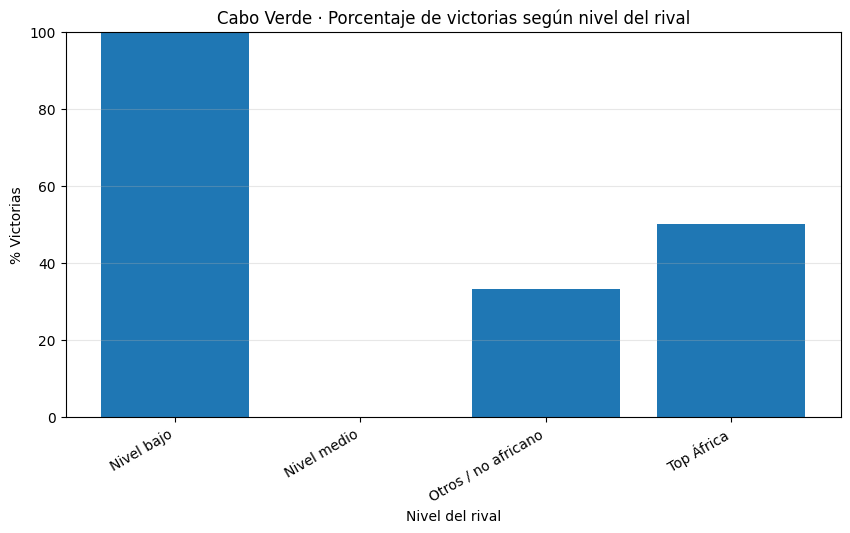

In [18]:
# ============================================================
# 21. Rendimiento según nivel del rival
# ============================================================

plt.figure(figsize=(10, 5))

plt.bar(
    rendimiento_por_nivel["Nivel_Rival"],
    rendimiento_por_nivel["% Victorias"]
)

plt.title("Cabo Verde · Porcentaje de victorias según nivel del rival")
plt.xlabel("Nivel del rival")
plt.ylabel("% Victorias")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)

plt.show()

## 22. Fortaleza ofensiva y defensiva

A partir de los datos limpios se calculan indicadores que resumen el rendimiento de Cabo Verde.

### Fortaleza ofensiva

- Promedio de goles a favor por partido.
- Partidos sin marcar.
- Partidos marcando dos o más goles.

### Fortaleza defensiva

- Promedio de goles encajados por partido.
- Porterías a cero.
- Diferencia de goles.


In [19]:
# ============================================================
# 22. Indicadores ofensivos y defensivos de Cabo Verde
# ============================================================

indicadores_cabo_verde = pd.DataFrame({
    "Indicador": [
        "Goles favor / partido",
        "Goles contra / partido",
        "% Porterías a cero",
        "% Partidos sin marcar",
        "% Partidos con 2+ goles",
        "% Victorias oficiales",
        "Partidos resueltos tras empate"
    ],
    "Valor": [
        resumen_cabo_verde["Goles favor / partido"],
        resumen_cabo_verde["Goles contra / partido"],
        resumen_cabo_verde["% Porterías a cero"],
        resumen_cabo_verde["% Partidos sin marcar"],
        resumen_cabo_verde["% Partidos con 2+ goles"],
        resumen_cabo_verde["% Victorias oficiales"],
        resumen_cabo_verde["Partidos resueltos tras empate"]
    ]
})

indicadores_cabo_verde

,Indicador,Valor
0,Goles favor / partido,1.62
1,Goles contra / partido,1.12
2,% Porterías a cero,50.00
3,% Partidos sin marcar,12.50
4,% Partidos con 2+ goles,50.00
5,% Victorias oficiales,50.00
6,Partidos resueltos tras empate,3.00


## 23. Comparación con España

La comparación con España se realiza utilizando la misma fuente y el mismo proceso de limpieza. De esta forma, ambas selecciones se comparan con criterios homogéneos.

La comparación tiene carácter orientativo porque el número de partidos disponibles para cada selección puede no ser igual. Aun así, permite contextualizar el rendimiento reciente de Cabo Verde frente a una selección de máximo nivel como España.

Las métricas seleccionadas son:

- Porcentaje de victorias oficiales.
- Goles a favor por partido.
- Goles encajados por partido.
- Porcentaje de porterías a cero.
- Porcentaje de partidos con dos o más goles.
- Porcentaje de partidos sin marcar.


In [20]:
# ============================================================
# 23. Comparativa España vs Cabo Verde
# ============================================================

metricas_comparacion = pd.DataFrame({
    "Métrica": [
        "Partidos disponibles",
        "% Victorias oficiales",
        "Goles favor / partido",
        "Goles contra / partido",
        "% Porterías a cero",
        "% Partidos con 2+ goles",
        "% Partidos sin marcar"
    ],
    "Cabo Verde": [
        resumen_cabo_verde["Partidos disponibles"],
        resumen_cabo_verde["% Victorias oficiales"],
        resumen_cabo_verde["Goles favor / partido"],
        resumen_cabo_verde["Goles contra / partido"],
        resumen_cabo_verde["% Porterías a cero"],
        resumen_cabo_verde["% Partidos con 2+ goles"],
        resumen_cabo_verde["% Partidos sin marcar"]
    ],
    "España": [
        resumen_espana["Partidos disponibles"],
        resumen_espana["% Victorias oficiales"],
        resumen_espana["Goles favor / partido"],
        resumen_espana["Goles contra / partido"],
        resumen_espana["% Porterías a cero"],
        resumen_espana["% Partidos con 2+ goles"],
        resumen_espana["% Partidos sin marcar"]
    ]
})

metricas_comparacion

,Métrica,Cabo Verde,España
0,Partidos disponibles,8.00,6.00
1,% Victorias oficiales,50.00,83.33
2,Goles favor / partido,1.62,3.50
3,Goles contra / partido,1.12,0.33
4,% Porterías a cero,50.00,83.33
5,% Partidos con 2+ goles,50.00,100.00
6,% Partidos sin marcar,12.50,0.00


## 24. Visualización 5: comparativa España vs Cabo Verde

Para que la visualización sea más interpretable, excluyo del gráfico la fila de `Partidos disponibles`, ya que es una variable de tamaño de muestra y no una métrica de rendimiento.


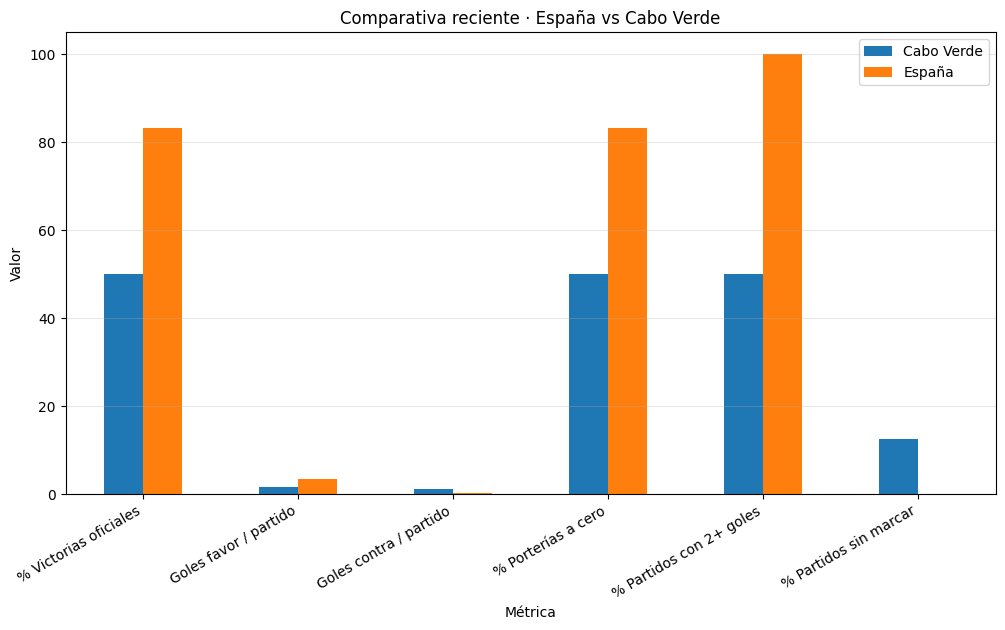

In [21]:
# ============================================================
# 24. Gráfico comparativo España vs Cabo Verde
# ============================================================

metricas_grafico = metricas_comparacion[
    metricas_comparacion["Métrica"] != "Partidos disponibles"
].copy()

metricas_comparacion_plot = metricas_grafico.set_index("Métrica")

ax = metricas_comparacion_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Comparativa reciente · España vs Cabo Verde")
plt.xlabel("Métrica")
plt.ylabel("Valor")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.show()

## 25. Automatización del proceso

Para cumplir con la parte de automatización, encapsulo el flujo completo en una función. Esta función permite repetir el proceso de scraping, limpieza, análisis y guardado de CSV de forma sencilla.


In [22]:
# ============================================================
# 25. Función de automatización
# ============================================================

def ejecutar_pipeline_11v11(n_ultimos=30, solo_oficiales=True):
    """
    Automatiza el proceso completo:
    1. Revisión informativa de robots.txt.
    2. Descarga de datos desde 11v11.
    3. Selección de tablas.
    4. Limpieza y normalización.
    5. Guardado en CSV.
    6. Generación de resumen comparativo.
    """
    logging.info("Inicio del pipeline automatizado")

    comprobar_robots(URL_CABO_VERDE)
    comprobar_robots(URL_ESPANA)

    tablas_cv = extraer_tablas_11v11(URL_CABO_VERDE)
    raw_cv = seleccionar_tabla_partidos(tablas_cv)

    df_cv = normalizar_partidos(
        raw_cv,
        "Cabo Verde",
        VARIANTES_CABO_VERDE,
        n_ultimos,
        solo_oficiales
    )

    tablas_es = extraer_tablas_11v11(URL_ESPANA)
    raw_es = seleccionar_tabla_partidos(tablas_es)

    df_es = normalizar_partidos(
        raw_es,
        "España",
        VARIANTES_ESPANA,
        n_ultimos,
        solo_oficiales
    )

    ruta_cv = os.path.join(DATA_DIR, "pipeline_cabo_verde.csv")
    ruta_es = os.path.join(DATA_DIR, "pipeline_espana.csv")

    df_cv.to_csv(ruta_cv, index=False, encoding="utf-8-sig")
    df_es.to_csv(ruta_es, index=False, encoding="utf-8-sig")

    resumen = pd.DataFrame({
        "Cabo Verde": resumen_equipo(df_cv),
        "España": resumen_equipo(df_es)
    })

    logging.info("Pipeline automatizado finalizado correctamente")

    return df_cv, df_es, resumen


# Ejemplo de uso:
# df_cv_auto, df_es_auto, resumen_auto = ejecutar_pipeline_11v11(n_ultimos=30, solo_oficiales=True)

## 26. Detección básica de cambios en la estructura de la web

Una parte importante de un scraper es detectar si la estructura de la web ha cambiado. Para ello, se valida si las columnas mínimas esperadas siguen presentes en la tabla extraída.


In [23]:
# ============================================================
# 26. Control básico de estructura
# ============================================================

def validar_estructura(df_raw: pd.DataFrame):
    columnas = set([str(c).strip() for c in df_raw.columns])
    columnas_minimas = {"Date", "Match", "Score"}

    faltantes = columnas_minimas - columnas

    if faltantes:
        mensaje = f"Alerta: faltan columnas esperadas en la tabla: {faltantes}"
        logging.warning(mensaje)
        print(mensaje)
        return False

    else:
        mensaje = "Estructura validada correctamente."
        logging.info(mensaje)
        print(mensaje)
        return True


validar_estructura(tabla_cabo_verde_raw)

Estructura validada correctamente.


True

## 27. Interpretación deportiva

A partir de los datos analizados, el enfoque del informe se centra en valorar a Cabo Verde como rival de España.

11v11 no proporciona datos tácticos avanzados ni plantillas detalladas, por lo que no sería correcto inventar información sobre once titular, edad media, clubes de procedencia o experiencia individual. Por este motivo, el análisis se limita a variables que sí están disponibles en la fuente utilizada.

Desde el punto de vista deportivo, los indicadores más relevantes son:

- Si Cabo Verde presenta un porcentaje alto de victorias oficiales, puede llegar con dinámica positiva.
- Si encaja pocos goles, puede ser un rival incómodo en un debut mundialista.
- Si tiene muchos partidos sin marcar, puede tener dificultades para castigar a una selección dominante.
- Si compite bien frente a rivales de nivel alto o medio, su rendimiento no debe subestimarse.
- La comparación con España ayuda a contextualizar la diferencia competitiva entre ambas selecciones.

También es importante separar goles y resultado oficial. En partidos decididos posteriormente, como tandas de penaltis, el marcador principal puede estar empatado, pero el resultado oficial aparece como victoria o derrota en 11v11.


## 28. Limitaciones del estudio

El estudio tiene varias limitaciones:

- La fuente 11v11 no proporciona métricas avanzadas como xG, posesión, tiros o pases.
- No se dispone de datos individuales de jugadores.
- No se analizan edad media, clubes de procedencia ni posible once titular.
- El número de partidos disponibles puede ser inferior al número solicitado.
- La clasificación del nivel de los rivales es una decisión analítica manual.
- Los partidos resueltos tras empate requieren interpretación separada entre marcador principal y resultado oficial.
- La comparación con España tiene carácter orientativo si el número de partidos disponibles es distinto.
- El análisis depende de la estructura HTML disponible en 11v11.
- Los datos pueden variar si la web actualiza su contenido o modifica su estructura.

Aun así, la fuente permite construir un análisis competitivo sólido basado en resultados, goles, rivales y comparación entre selecciones.


## 29. Conclusión final

El proyecto demuestra que una única fuente web puede ser suficiente para realizar un análisis deportivo relevante si se define bien la pregunta de investigación. En este caso, 11v11 permite extraer partidos disponibles de Cabo Verde y España, limpiar los datos, calcular métricas de rendimiento y generar visualizaciones útiles para preparar el contexto del enfrentamiento mundialista.

Desde el punto de vista deportivo, Cabo Verde presenta un rendimiento competitivo aceptable antes del Mundial 2026. La selección obtiene un 50% de victorias oficiales y mantiene la portería a cero en la mitad de los encuentros analizados. Además, muestra capacidad para competir en partidos cerrados, aunque varios de ellos se resolvieron posteriormente tras empate, por lo que es importante interpretar por separado el marcador principal y el resultado oficial.

La comparación con España muestra diferencias importantes tanto en capacidad ofensiva como en regularidad competitiva. España alcanza un 83,33% de victorias oficiales y una media de 3,5 goles por partido, mientras que Cabo Verde registra 1,62 goles por encuentro. También existe diferencia en el promedio de goles encajados, ya que España presenta mayor solidez defensiva en la muestra disponible.

Aun así, Cabo Verde no debe analizarse únicamente por su nombre o historial. Su capacidad para mantener partidos igualados y dejar la portería a cero puede convertir el enfrentamiento en un partido más exigente de lo que indica la diferencia histórica entre ambas selecciones. Para España, el principal riesgo estaría en no abrir pronto el marcador y permitir que Cabo Verde mantenga un bloque defensivo competitivo durante muchos minutos.

A nivel técnico, el trabajo incluye scraping con `requests`, inspección inicial con `BeautifulSoup`, extracción de tablas con `pandas.read_html`, limpieza de datos, creación de variables, exportación a CSV, visualizaciones, logging, control de errores, pausas entre peticiones, comprobación informativa de `robots.txt` y una función automatizada para repetir el proceso. Esto permite construir un flujo de trabajo reproducible y alineado con los objetivos del módulo.


## 30. Archivos generados

Durante la ejecución del notebook se generan los siguientes archivos:

- `datos_tarea4_cabo_verde/partidos_cabo_verde_11v11_limpios.csv`
- `datos_tarea4_cabo_verde/partidos_espana_11v11_limpios.csv`
- `datos_tarea4_cabo_verde/scraping_tarea4.log`

Estos archivos complementan el notebook y permiten revisar tanto los datos extraídos como el registro del proceso.
